In [60]:
# import requests
import pandas as pd
import numpy as np
from scipy.stats import entropy
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
# from statsmodels.tsa.stattools import adfuller  
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import root_mean_squared_error , mean_absolute_error , mean_absolute_percentage_error          

import itertools

import time
# import yaml
pd.options.display.float_format = '{:,.2f}'.format
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

## 1. Data Preparation

In [61]:
df_merged_detrended = pd.read_csv("dataset_FINAL_all_variables.csv")


In [62]:
df_merged_detrended.columns

Index(['date', 'workforce', 'inactives', 'employment_rate',
       'youth_employment_rate', 'activity_rate', 'unemployment_rate',
       'industry_production_prices', 'companies_trust', 'gasoline_car_price',
       'diesel_price', 'GPL_price', 'diesel_heatining_price', 'workforce_diff',
       'inactives_diff', 'employment_rate_diff', 'activity_rate_diff',
       'unemployment_rate_diff', 'industry_production_prices_diff',
       'companies_trust_diff', 'gasoline_car_price_diff', 'diesel_price_diff',
       'GPL_price_diff', 'year', 'month', 'PCA_labour_market_1',
       'PCA_labour_market_2', 'PCA_price_energy_1', 'PCA_price_energy_2',
       'rolling_mean_3m', 'rolling_mean_6m', 'rolling_mean_12m',
       'rolling_std_12m'],
      dtype='str')

In [63]:
df_merged_detrended = df_merged_detrended[[ 'date',
                                            # 'year', 
                                            'month',
                                            # 'working_days_diff',
                                            'employment_rate_diff', 
                                            'industry_production_prices_diff', 
                                            'companies_trust',
                                            'rolling_mean_3m', 
                                            'rolling_mean_6m',
                                            'rolling_mean_12m', 
                                            'rolling_std_12m', 
                                            # 'lag_1m',  lagged variables caused data leakage --> fix thin the data cleaner notebook
                                            # 'lag_2m', 
                                            # 'lag_3m', #'lag_12m', 
                                            'PCA_labour_market_1', 
                                            'PCA_labour_market_2',
                                            'PCA_price_energy_1', 
                                            'PCA_price_energy_2',
                                            'unemployment_rate', 
                                            'unemployment_rate_diff'
                                            ]]

In [64]:
X_columns = df_merged_detrended.drop(['unemployment_rate','unemployment_rate_diff'], axis = 1)
X_columns.tail(4)

,date,month,employment_rate_diff,industry_production_prices_diff,companies_trust,rolling_mean_3m,rolling_mean_6m,rolling_mean_12m,rolling_std_12m,PCA_labour_market_1,PCA_labour_market_2,PCA_price_energy_1,PCA_price_energy_2
233,2025-10-01,10,0.23,-0.30,94.40,-0.10,-0.10,-0.02,0.61,-0.16,0.01,-415.79,0.00
234,2025-11-01,11,-0.65,1.20,96.00,0.07,-0.26,-0.03,0.61,-1.97,0.02,-415.76,0.01
235,2025-12-01,12,0.07,-0.90,96.40,-0.07,-0.16,-0.08,0.56,0.69,0.00,-415.82,0.00
236,2026-01-01,1,0.60,1.80,97.50,-0.14,-0.12,-0.17,0.55,0.46,-0.01,-415.81,0.00


In [65]:
X_columns['date'] = pd.to_datetime(X_columns['date'])
X_columns = X_columns.set_index('date')
df_merged_detrended['date'] = pd.to_datetime(df_merged_detrended['date'])
df_merged_detrended = df_merged_detrended.set_index('date')



In [66]:
len_pred = 6

exog_train = X_columns.iloc[5:-24]
exog_val = X_columns.iloc[-24:-len_pred]
exog_test = X_columns.iloc[-len_pred:]

y_train = df_merged_detrended.iloc[5:-24]['unemployment_rate_diff']
y_val = df_merged_detrended.iloc[-24:-len_pred]['unemployment_rate_diff']
y_test = df_merged_detrended.iloc[-len_pred:]['unemployment_rate_diff']

In [67]:
selected_cols = ['month', 
                        # 'working_days_diff',
                        'employment_rate_diff', 
                        'industry_production_prices_diff',
                        'companies_trust', 
                        # 'rolling_mean_3m', 
                        'rolling_mean_6m',
                        'rolling_mean_12m', 
                        # 'rolling_std_12m', 
                        'PCA_labour_market_1',
                        'PCA_labour_market_2', 
                        'PCA_price_energy_1', 
                        'PCA_price_energy_2'
                        ]

## 2. Model: SARIMAX

SARIMAX(p, d, q) × (P, D, Q, s)

p = 0 → componente autoregressiva
p indica quanti lag della variabile dipendente vengono utilizzati nella componente AR (autoregressiva).

d = 0 → differenziazione
d indica quante volte viene differenziata la serie nella parte non stagionale.

q = 0 → componente MA
q indica quanti lag degli errori/residui precedenti vengono utilizzati nella componente Moving Average.


D = 0 → niente differenziazione stagionale

Q = 0 → nessuna componente MA stagionale

s = 12 → periodicità stagionale

In [68]:
# best_param = (1, 1, 0)
# best_param_seasonal = (0, 1, 0, 12)

best_param = (1, 0, 1)
best_param_seasonal = (2, 0,1, 12)

In [69]:
model = SARIMAX(y_train,
                exog=exog_train[selected_cols], 
                order=best_param,
                seasonal_order=best_param_seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit()


y_val_pred = results.predict(
    start=exog_val.index[0],
    end=exog_val.index[-1],
    exog=exog_val[selected_cols]
)


#################################################################
######################## TESTING  ###############################
#################################################################
exog_future = pd.concat([exog_val,  exog_test])

y_test_pred = results.predict(
        start=exog_test.index[0],
        end=exog_test.index[-1],
        exog=exog_future[selected_cols]
            )

In [70]:
val_rmse = round(root_mean_squared_error(y_val, y_val_pred), 5)
# val_mae = mean_absolute_error(y_val, y_val_pred)

val_rmse

0.01604

In [71]:
test_rmse = round(root_mean_squared_error(y_test, y_test_pred), 5 )
# test_mae = round(mean_absolute_error(y_test, y_test_pred)
       

test_rmse

0.03298

In [72]:
y_original = df_merged_detrended['unemployment_rate_diff'].iloc[-13] 

In [73]:
# Reversing the difference:
anchor =  df_merged_detrended['unemployment_rate'].iloc[-13] 
final_forecast = y_test_pred.cumsum() + anchor

# PERFORMANCES

In [74]:
print("------------------ NO rolling mean 3 + rolling std 12 + PCA_labour_market_2 + working_days_diff -------------------------") 
print(f"RMSE val: {round(root_mean_squared_error(y_val, y_val_pred),5)}"), 
print(f"RMSE test : {round(root_mean_squared_error(y_test, y_test_pred), 5)}")
                                        

------------------ NO rolling mean 3 + rolling std 12 + PCA_labour_market_2 + working_days_diff -------------------------
RMSE val: 0.01604
RMSE test : 0.03298


# Data visualization

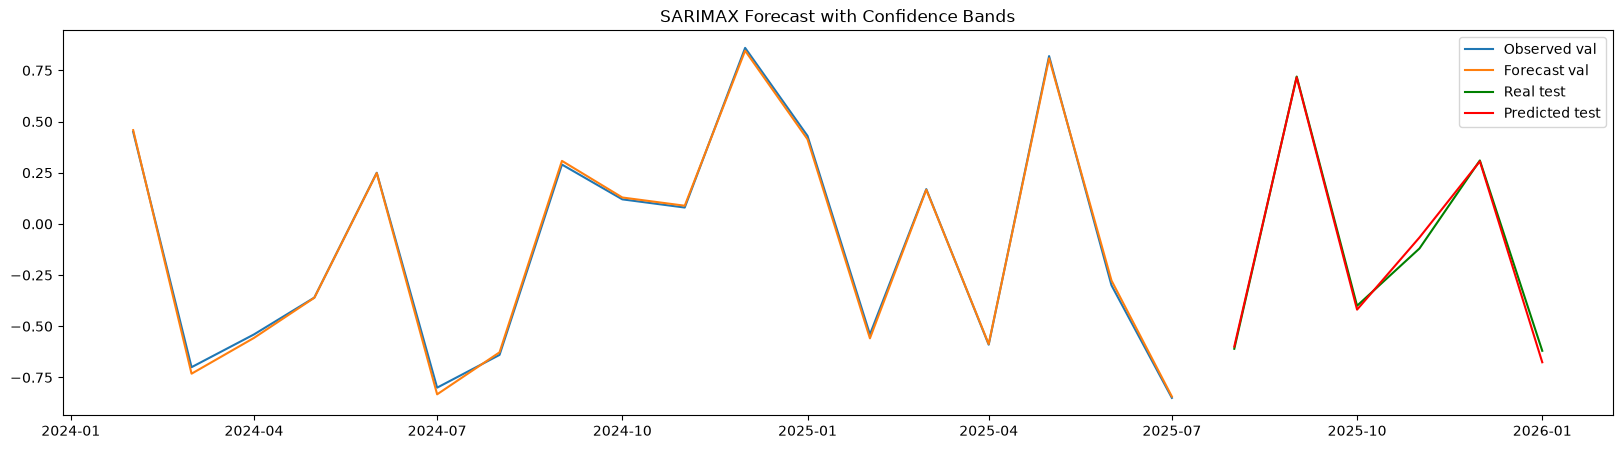

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

plt.plot(y_val.index, y_val, label='Observed val')
plt.plot(y_val_pred.index, y_val_pred, label='Forecast val', color='C1')
plt.plot(y_test.index, y_test, label='Real test', color = 'green')
plt.plot(y_test_pred.index, y_test_pred, label='Predicted test', color = 'red')

# plt.fill_between(
#     forecast_mean.index,
#     conf_int.iloc[:, 0],
#     conf_int.iloc[:, 1],
#     color='C1',
#     alpha=0.3,
#     label='95% CI'
# )

plt.legend()
plt.title("SARIMAX Forecast with Confidence Bands")
plt.show()


# Back up

### Plotting results

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

plt.plot(y_train.iloc[-h:].index, y_train.iloc[-h:], label='Observed')
plt.plot(y_pred.iloc[-h:].index, y_pred.iloc[-h:], label='Forecast', color='C1')
plt.plot(y_test.index, y_test, label='Real', color = 'green')

# plt.fill_between(
#     forecast_mean.index,
#     conf_int.iloc[:, 0],
#     conf_int.iloc[:, 1],
#     color='C1',
#     alpha=0.3,
#     label='95% CI'
# )

plt.legend()
plt.title("SARIMAX Forecast with Confidence Bands")
plt.show()


NameError: name 'h' is not defined

<Figure size 2000x500 with 0 Axes>

In [ ]:
anchor =  df_merged_detrended['unemployment_rate'].iloc[-13] 
final_forecast = forecast_mean_test.cumsum() + anchor

In [ ]:
df_merged_detrended

,year,month,employment_rate_diff,industry_production_prices_diff,companies_trust,rolling_mean_3m,rolling_mean_6m,rolling_mean_12m,rolling_std_12m,lag_1m,lag_2m,lag_3m,PCA_labour_market_1,PCA_labour_market_2,PCA_price_energy_1,PCA_price_energy_2,unemployment_rate,unemployment_rate_diff
date,,,,,,,,,,,,,,,,,,
2014-02-01,2014,2,1.12,0.00,87.30,0.25,0.50,0.07,0.80,1.72,-0.95,0.26,1.01,0.01,0.06,0.13,14.13,-0.02
2014-03-01,2014,3,0.17,-0.20,89.20,0.32,0.15,0.04,0.83,-0.02,1.72,-0.95,1.32,0.01,0.04,0.10,13.40,-0.73
2014-04-01,2014,4,-1.24,-0.20,88.30,-0.35,-0.00,0.03,0.83,-0.73,-0.02,1.72,-2.75,0.00,0.03,0.08,13.10,-0.30
2014-05-01,2014,5,2.21,-0.10,87.60,-0.38,-0.07,0.04,0.83,-0.30,-0.73,-0.02,1.92,0.01,0.05,0.07,12.98,-0.12
2014-06-01,2014,6,-0.40,0.20,89.30,-0.64,-0.16,-0.03,0.92,-0.12,-0.30,-0.73,-1.47,-0.01,0.04,0.07,11.48,-1.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01,2025,9,0.78,0.30,93.80,-0.25,-0.13,0.03,0.60,-0.61,-0.85,-0.30,1.41,0.00,0.02,0.01,6.04,0.72
2025-10-01,2025,10,-0.83,-0.30,94.40,-0.10,-0.10,-0.02,0.61,0.72,-0.61,-0.85,-0.17,0.02,-0.01,0.02,5.64,-0.40
2025-11-01,2025,11,-0.28,1.20,96.10,0.07,-0.26,-0.03,0.61,-0.40,0.72,-0.61,-1.94,0.03,0.07,-0.02,5.52,-0.12


In [ ]:
final_forecast

2025-02-01   6.68
2025-03-01   6.85
2025-04-01   6.26
2025-05-01   7.08
2025-06-01   6.78
2025-07-01   5.93
2025-08-01   5.32
2025-09-01   6.04
2025-10-01   5.64
2025-11-01   5.52
2025-12-01   5.83
2026-01-01   5.21
Freq: MS, Name: predicted_mean, dtype: float64

In [ ]:
df_merged_detrended['unemployment_rate'].tail(12)

date
2025-02-01   6.68
2025-03-01   6.85
2025-04-01   6.26
2025-05-01   7.08
2025-06-01   6.78
2025-07-01   5.93
2025-08-01   5.32
2025-09-01   6.04
2025-10-01   5.64
2025-11-01   5.52
2025-12-01   5.83
2026-01-01   5.21
Name: unemployment_rate, dtype: float64

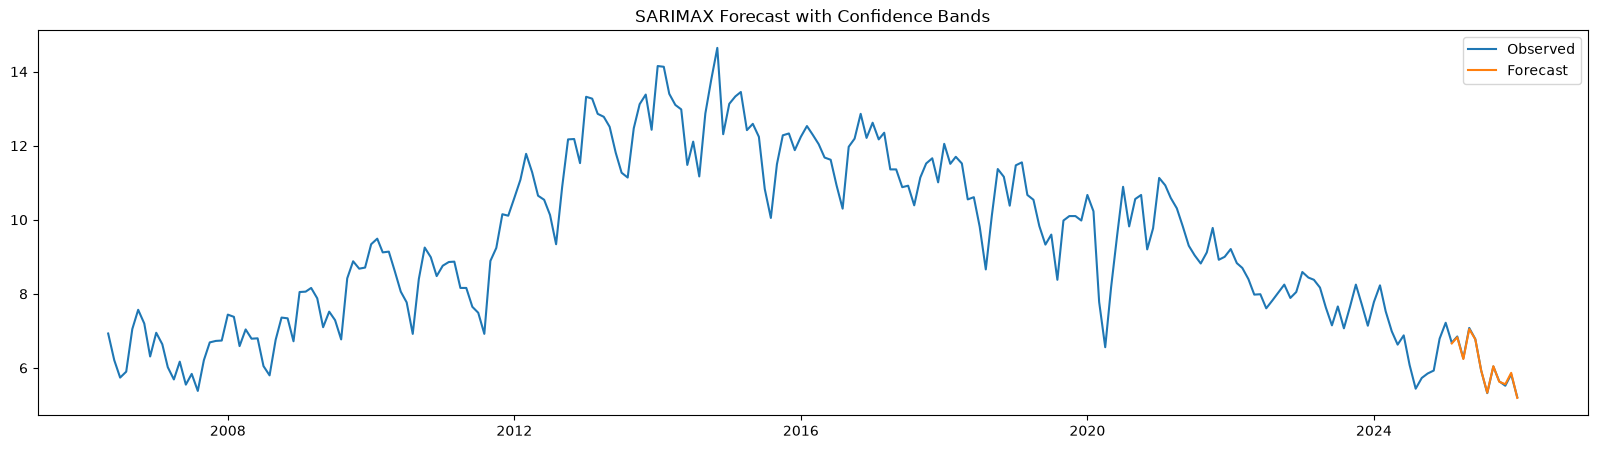

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

plt.plot(df_merged_detrended.index, df_merged_detrended['unemployment_rate'], label='Observed')
plt.plot(final_forecast.index, final_forecast, label='Forecast', color='C1')
# plt.plot(y_test.index, y_test, label='Real', color = 'green')

# plt.fill_between(
#     forecast_mean.index,
#     conf_int.iloc[:, 0],
#     conf_int.iloc[:, 1],
#     color='C1',
#     alpha=0.3,
#     label='95% CI'
# )

plt.legend()
plt.title("SARIMAX Forecast with Confidence Bands")
plt.show()


## 3. Saving the models and parameters

In [ ]:
var_dict = {
"lags" : results.k_ar
,"variables": results.names
,"params" : results.params.to_dict()
# ,"sigma_u" : results.sigma_u.tolist()
#  ,"aic" : results.aic
#  ,"bic" : results.bic
}

AttributeError: 'SARIMAXResults' object has no attribute 'k_ar'

In [ ]:
from pathlib import Path
 
BASE_DIR = Path.cwd()   # current working directory
CONFIG_PATH = BASE_DIR / "configs" 

with open(CONFIG_PATH / "SARIMAX_baseline.yaml", "w") as f:
    yaml.safe_dump(var_dict)

In [ ]:
import pickle

BASE_DIR = Path.cwd()   # current working directory
PATH = BASE_DIR / "models" 

with open(PATH / "SARIMAX_model.pkl", "wb") as f:
    pickle.dump(results, f)